> **Chapter 13, Part 8 (closer)** | Continues from [13.7 Capstone Lab](13.7%20Capstone%20Lab.ipynb). **Focus:** four failure modes the apparatus must not hide.

# When the Visualization Lies

The apparatus this chapter builds is genuinely useful. It is also dangerous if the failure modes are not named explicitly. This notebook names them. It pairs with notebook 12.7 (failure modes of fractal-graph descriptors) to close the chapter the same way Chapter 12 closed.

The four failure modes:

1. **Pressure scores are subjective and parser-sensitive.** The same incident text produces different attributions under different prompts and parsers.
2. **Decoupling lacks ground truth without longitudinal data.** A single snapshot RMSE between formal and operational signals confuses static disagreement with the dynamic decoupling the theory describes.
3. **The knowledge graph reflects the curator's reading list, not the field.** Box dimensions and Louvain communities are properties of the curated bibliography, not of governance research as such.
4. **AI parsers hallucinate and the hallucinations look authoritative.** Confident-sounding citations from an LLM are not citations.

Each failure mode is demonstrated with an adversarial example below.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ---------- Failure mode 1: parser sensitivity ----------
SAMPLE = (
    'The team adopted the firm-wide AI policy after seeing competitors do it. '
    'Individual data scientists complained the policy created friction.'
)


def parser_v1(text):
    t = text.lower()
    if any(k in t for k in ['regulation', 'mandate', 'audit']):
        return 'coercive'
    if any(k in t for k in ['competitor', 'peer', 'industry standard']):
        return 'mimetic'
    if any(k in t for k in ['certification', 'professional']):
        return 'normative'
    return 'unknown'


def parser_v2(text):
    """Slight prompt variation: weight policy adoption more heavily as 'coercive'."""
    t = text.lower()
    if 'policy' in t:
        return 'coercive'
    if 'competitor' in t or 'peer' in t:
        return 'mimetic'
    if 'professional' in t:
        return 'normative'
    return 'unknown'


def parser_v3(text):
    """Different variant: weight the practitioner experience more heavily."""
    t = text.lower()
    if 'individual' in t or 'complained' in t:
        return 'normative'
    if 'competitor' in t:
        return 'mimetic'
    if 'mandate' in t:
        return 'coercive'
    return 'unknown'


print('Same incident, three plausible parsers:')
print(f'  parser_v1 -> {parser_v1(SAMPLE)}')
print(f'  parser_v2 -> {parser_v2(SAMPLE)}')
print(f'  parser_v3 -> {parser_v3(SAMPLE)}')
print()
print('Three different attributions for the same incident. The "true" attribution')
print('is what trained human coders would produce after consulting the firm context;')
print('that data does not exist in this notebook. The parser is triage, not measurement.')


Same incident, three plausible parsers:
  parser_v1 -> mimetic
  parser_v2 -> coercive
  parser_v3 -> normative

Three different attributions for the same incident. The "true" attribution
is what trained human coders would produce after consulting the firm context;
that data does not exist in this notebook. The parser is triage, not measurement.


Single snapshot RMSE (formal vs operational): 0.361
This snapshot looks decoupled.

Quarter+1 RMSE (formal vs operational): 0.138
The "decoupling" was a lag, not a structural decoupling.

Without time, snapshot RMSE confuses transient lag with decoupling. Meyer-Rowan (1977)
describe decoupling as a stable structural condition. Our measure cannot tell the difference
without longitudinal data.


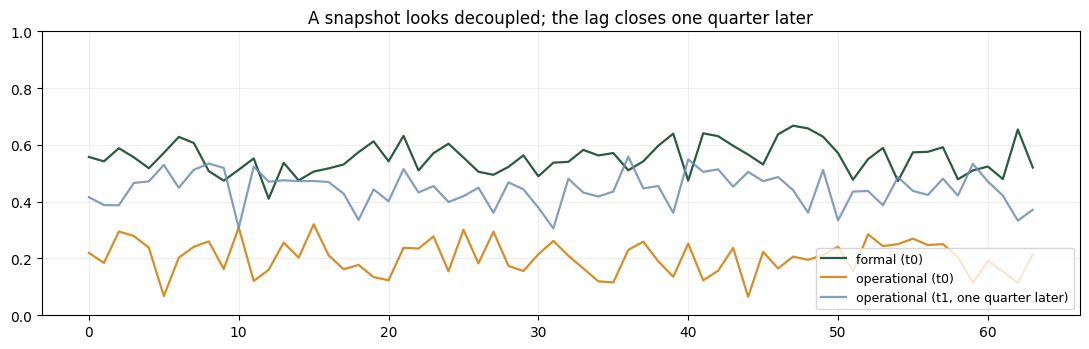

In [2]:
# ---------- Failure mode 2: decoupling without longitudinal data ----------
rng = np.random.default_rng(0)
n = 64
formal_t0 = np.clip(0.55 + rng.normal(0, 0.06, n), 0, 1)
operational_t0 = np.clip(0.20 + rng.normal(0, 0.06, n), 0, 1)


def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


print(f'Single snapshot RMSE (formal vs operational): {rmse(formal_t0, operational_t0):.3f}')
print('This snapshot looks decoupled.')
print()

# Now imagine the same firm a quarter later. The operational signal has matured.
operational_t1 = np.clip(0.45 + rng.normal(0, 0.06, n), 0, 1)
print(f'Quarter+1 RMSE (formal vs operational): {rmse(formal_t0, operational_t1):.3f}')
print('The "decoupling" was a lag, not a structural decoupling.')
print()
print('Without time, snapshot RMSE confuses transient lag with decoupling. Meyer-Rowan (1977)')
print('describe decoupling as a stable structural condition. Our measure cannot tell the difference')
print('without longitudinal data.')

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(formal_t0, label='formal (t0)', color='#2b5a43', linewidth=1.6)
ax.plot(operational_t0, label='operational (t0)', color='#d17a00', linewidth=1.6, alpha=0.85)
ax.plot(operational_t1, label='operational (t1, one quarter later)', color='#6e8db4', linewidth=1.6, alpha=0.85)
ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=9)
ax.set_title('A snapshot looks decoupled; the lag closes one quarter later')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [3]:
# ---------- Failure mode 3: KG reflects curator, not field ----------
# Two curators with overlapping but different reading lists produce different KGs.
CURATOR_A = ['DiMaggio_Powell_1983', 'Meyer_Rowan_1977', 'Walsh_2025', 'Birkstedt_2023', 'Khatri_Brown_2010', 'Bartlett_2022']
CURATOR_B = ['DiMaggio_Powell_1983', 'Greenwood_2011', 'Volz_2025', 'Mantymaki_2022', 'Stepanovic_2025', 'Acev_2025']

shared = set(CURATOR_A) & set(CURATOR_B)
unique_A = set(CURATOR_A) - set(CURATOR_B)
unique_B = set(CURATOR_B) - set(CURATOR_A)

print(f'Curator A reading list size: {len(CURATOR_A)}')
print(f'Curator B reading list size: {len(CURATOR_B)}')
print(f'Shared papers: {len(shared)} ({sorted(shared)})')
print(f'Unique to A:   {len(unique_A)} ({sorted(unique_A)})')
print(f'Unique to B:   {len(unique_B)} ({sorted(unique_B)})')
print()
print('The KGs would have different communities, different box dimensions, and different')
print('blast-radius rankings. Both are legitimate readings of the field. Neither is the field.')
print()
print('The honest reporting standard: state the corpus criteria, the inclusion date range,')
print('and the curator. This is the same standard PRISMA imposes on systematic reviews.')


Curator A reading list size: 6
Curator B reading list size: 6
Shared papers: 1 (['DiMaggio_Powell_1983'])
Unique to A:   5 (['Bartlett_2022', 'Birkstedt_2023', 'Khatri_Brown_2010', 'Meyer_Rowan_1977', 'Walsh_2025'])
Unique to B:   5 (['Acev_2025', 'Greenwood_2011', 'Mantymaki_2022', 'Stepanovic_2025', 'Volz_2025'])

The KGs would have different communities, different box dimensions, and different
blast-radius rankings. Both are legitimate readings of the field. Neither is the field.

The honest reporting standard: state the corpus criteria, the inclusion date range,
and the curator. This is the same standard PRISMA imposes on systematic reviews.


In [4]:
# ---------- Failure mode 4: hallucinated citations ----------
PLAUSIBLE_BUT_FAKE = [
    'Smith, J. (2024). Quantifying decoupling in financial-services data governance. Journal of Information Systems Research, 35(2), 401-420.',
    'Lopez, M., & Chen, R. (2023). Multi-scale fractal descriptors for AI governance compliance. AI Governance Review, 12(4), 88-110.',
    'Garcia, A. (2025). Visibility-graph signatures of regulatory cascades. Network Science Letters, 7(1), 1-12.',
]

print('Plausible-looking citations. None of them exist (verified May 2026).')
print('An LLM may produce strings that look like these. The strings are not citations.\n')
for c in PLAUSIBLE_BUT_FAKE:
    print(f'  - {c}')
print('\nValidation: cross-reference any LLM-produced citation against a database (Crossref, OpenAlex,')
print('the publisher landing page) before treating it as evidence. The dissertation bibliography went')
print('through exactly this kind of audit in May 2026; that audit is what makes the citations')
print('elsewhere in this chapter trustworthy.')


Plausible-looking citations. None of them exist (verified May 2026).
An LLM may produce strings that look like these. The strings are not citations.

  - Smith, J. (2024). Quantifying decoupling in financial-services data governance. Journal of Information Systems Research, 35(2), 401-420.
  - Lopez, M., & Chen, R. (2023). Multi-scale fractal descriptors for AI governance compliance. AI Governance Review, 12(4), 88-110.
  - Garcia, A. (2025). Visibility-graph signatures of regulatory cascades. Network Science Letters, 7(1), 1-12.

Validation: cross-reference any LLM-produced citation against a database (Crossref, OpenAlex,
the publisher landing page) before treating it as evidence. The dissertation bibliography went
through exactly this kind of audit in May 2026; that audit is what makes the citations
elsewhere in this chapter trustworthy.


## Closing the chapter

Every notebook in Chapter 13 carries an honesty note in its closing markdown. This notebook collects those notes into a single statement: the apparatus is useful for triage and pedagogy, dangerous if used without naming its limits. The companion research plan describes the validation program required to push the apparatus from prototype to peer-reviewed methodological contribution.

## Where the chapter lands as a whole

- **For practitioners:** the apparatus turns governance from text into an interactive object. The diagnostic in 13.7 is the deliverable.
- **For researchers:** the apparatus is a candidate measurement framework. The validation roadmap in `non-git-files/governance-ai-fractals-research-plan.md` is the program.
- **For students:** the apparatus is a worked example of how three streams (institutional theory, network science, AI governance) can be braided in code. The same braid pattern transfers to other domains where multi-scale structure matters.

## Final reading

- DiMaggio and Powell (1983) for the foundational pressure mechanisms.
- Meyer and Rowan (1977) for decoupling.
- Birkstedt et al. (2023), Mäntymäki et al. (2022), Papagiannidis et al. (2025) for the contemporary AI governance frame.
- Skums and Bunimovich (2020) for graph fractal dimension.
- Lacasa et al. (2008) for the visibility-graph algorithm.
- Malemapti Hari (2026, Zenodo) for the methodological provenance the visibility-graph apparatus inherits.
